Weather Data Fetched Successfully!

Weather Data:

         Date  Temperature  Humidity  Wind Speed
0  2026-05-20           26        72          19
1  2026-05-21           27        79          23
2  2026-05-22           26        72          21

CSV File Saved Successfully!


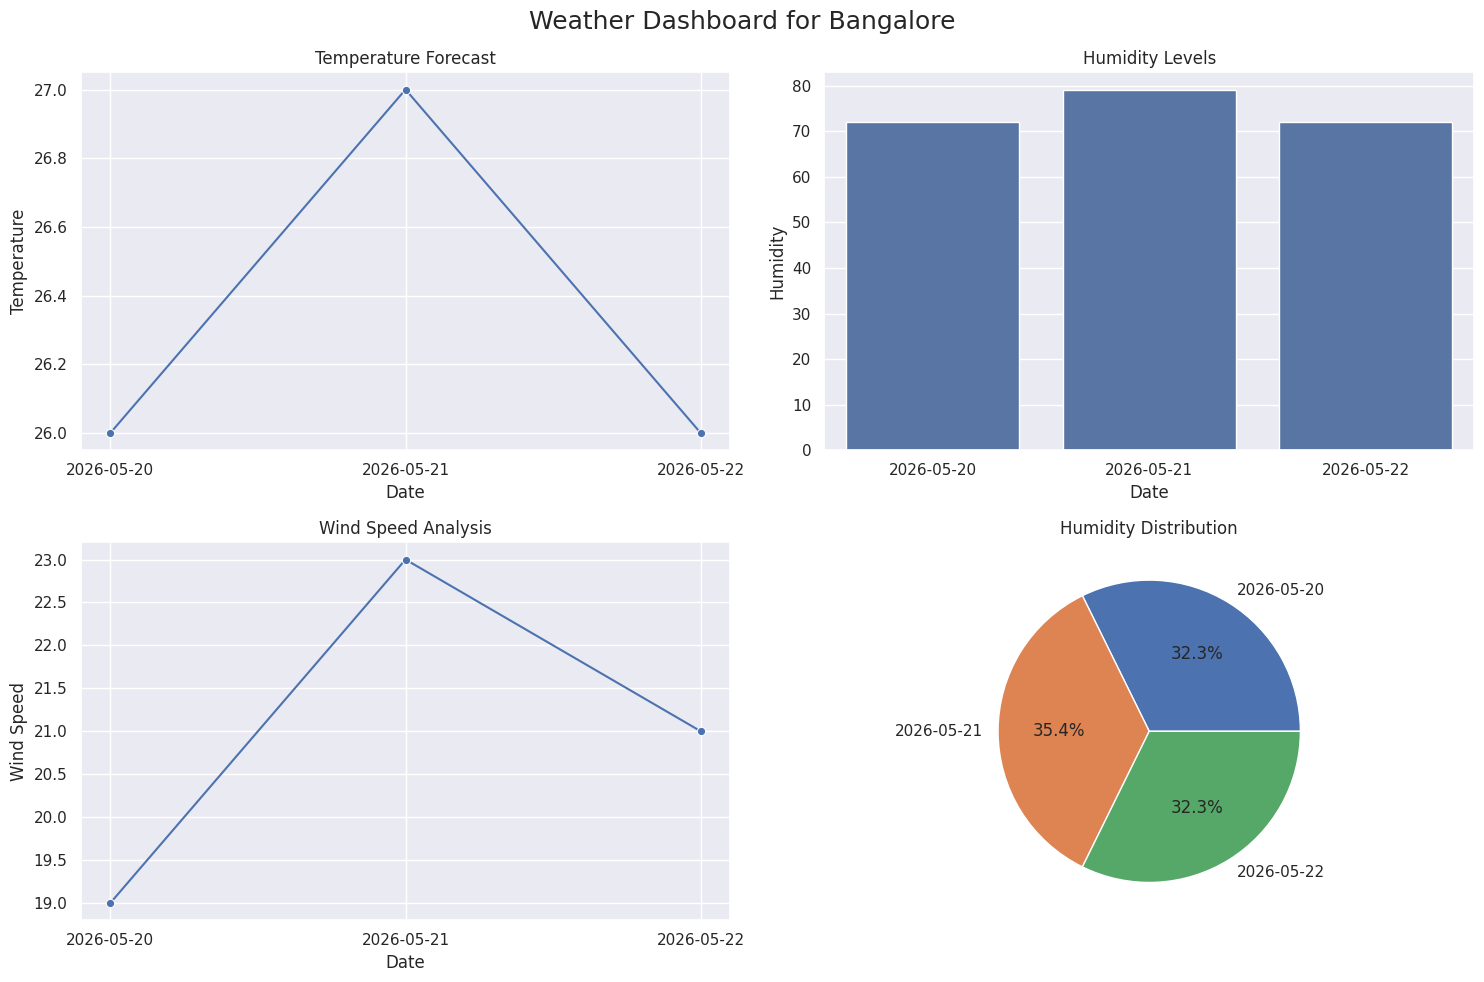


Dashboard Created Successfully!
weather_dashboard.png Saved
weather_data.csv Saved


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# API INTEGRATION AND DATA VISUALIZATION PROJECT

CITY = "Bangalore"

# PUBLIC WEATHER API
URL = f"https://wttr.in/{CITY}?format=j1"

# FETCH DATA FROM API

response = requests.get(URL)

if response.status_code != 200:
    print("Error Fetching Data")
    exit()

data = response.json()

print("Weather Data Fetched Successfully!")

# PROCESS DATA

weather_data = []

for item in data['weather']:

    weather_data.append({

        "Date": item['date'],
        "Temperature": int(item['avgtempC']),
        "Humidity": int(item['hourly'][0]['humidity']),
        "Wind Speed": int(item['hourly'][0]['windspeedKmph'])

    })

# CREATE DATAFRAME

df = pd.DataFrame(weather_data)

print("\nWeather Data:\n")
print(df)

# SAVE CSV FILE

df.to_csv("weather_data.csv", index=False)

print("\nCSV File Saved Successfully!")

# VISUALIZATION SETTINGS

sns.set(style="darkgrid")

plt.figure(figsize=(15, 10))

# TEMPERATURE GRAPH

plt.subplot(2, 2, 1)

sns.lineplot(
    x="Date",
    y="Temperature",
    data=df,
    marker='o'
)

plt.title("Temperature Forecast")

# HUMIDITY GRAPH

plt.subplot(2, 2, 2)

sns.barplot(
    x="Date",
    y="Humidity",
    data=df
)

plt.title("Humidity Levels")

# WIND SPEED GRAPH

plt.subplot(2, 2, 3)

sns.lineplot(
    x="Date",
    y="Wind Speed",
    data=df,
    marker='o'
)

plt.title("Wind Speed Analysis")


# PIE CHART


plt.subplot(2, 2, 4)

plt.pie(
    df["Humidity"],
    labels=df["Date"],
    autopct='%1.1f%%'
)

plt.title("Humidity Distribution")


# FINAL DASHBOARD

plt.suptitle(
    f"Weather Dashboard for {CITY}",
    fontsize=18
)

plt.tight_layout()

# SAVE DASHBOARD IMAGE

plt.savefig("weather_dashboard.png")

# SHOW DASHBOARD

plt.show()

# FINAL MESSAGE

print("\nDashboard Created Successfully!")
print("weather_dashboard.png Saved")
print("weather_data.csv Saved")